In [1]:
import seaborn as sns
from scipy.stats import mannwhitneyu
import pandas as pd
import pickle
import json
import random
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 6,
    'axes.titlesize': 6,
    'axes.labelsize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'figure.titlesize': 6,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [2]:
# Load data
ptm_contact_dic = pickle.load(
    open("./data/cRDH.PTM.intra_interaction.summary.pkl", "rb")
)
seq_feature_dic = json.load(open("./data/cRDH.secondary_structure_anno.json", "r"))
histMTR_df = pd.read_csv("./data/cRDH.HistMTR.obs_RGC.pred_MuRaL.tsv", sep="\t")

In [3]:
for family, df in histMTR_df.groupby("family"):

    for anno_seq in ptm_contact_dic[family]:

        if anno_seq["label"] == "PTM":
            site_idx = [i for i, c in enumerate(anno_seq["color"]) if c != "azure"]
            histMTR_df.loc[
                (histMTR_df["family"] == family) & (histMTR_df["pos"].isin(site_idx)),
                "PTM",
            ] = 1

        if anno_seq["label"] in ["H2A", "H2B", "H3", "H4"]:
            site_idx = [i for i, c in enumerate(anno_seq["color"]) if c != "#FFF0ED"]
            histMTR_df.loc[
                (histMTR_df["family"] == family) & (histMTR_df["pos"].isin(site_idx)),
                "have_interact",
            ] = 1

# Fill NaN (no PTM/contact) with 0
histMTR_df[["PTM", "have_interact"]] = histMTR_df[["PTM", "have_interact"]].fillna(0)
# Exclude start codon
histMTR_df = histMTR_df[histMTR_df["pos"] != 0]

In [5]:
histMTR_df["domain"] = "Globular"
# Define domain
for family, info in seq_feature_dic.items():
    for feature in info:
        if "tail" in feature["label"]:
            ss, es = feature["range"]
            histMTR_df.loc[
                (histMTR_df["family"] == family)
                & (histMTR_df["pos"] >= ss)
                & (histMTR_df["pos"] <= es),
                "domain",
            ] = "Tails"

In [6]:
histMTR_df["PTM"] = histMTR_df["PTM"].astype(int)
histMTR_df["have_interact"] = histMTR_df["have_interact"].astype(int)

# Create combination (PTM and interaction)
histMTR_df["combo"] = (
    histMTR_df["PTM"].map({0: "P0", 1: "P1"})
    + "_"
    + histMTR_df["have_interact"].map({0: "I0", 1: "I1"})
)

p_values = {}
order = ["P0_I0", "P0_I1", "P1_I0", "P1_I1"]

for combo1, combo2 in combinations(order, 2):
    group1 = histMTR_df[histMTR_df["combo"] == combo1]["HistMTR"]
    group2 = histMTR_df[histMTR_df["combo"] == combo2]["HistMTR"]
    stat, pvalue = mannwhitneyu(
        group1.dropna().tolist(), group2.dropna().tolist()
    )
    p_values[f"{combo1} vs {combo2}"] = pvalue

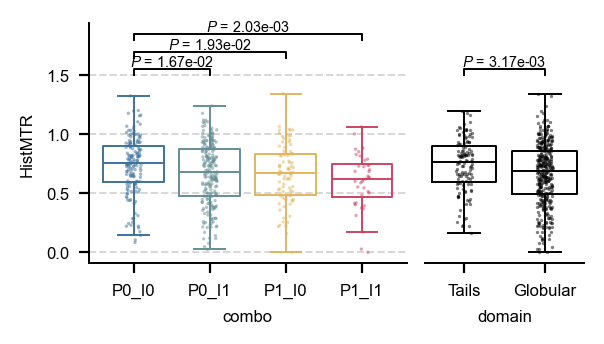

In [8]:
seed = 42
random.seed(seed)
np.random.seed(seed)

plt.rcParams["figure.dpi"] = 200
order = ["P0_I0", "P0_I1", "P1_I0", "P1_I1"]

fig, axes = plt.subplots(1, 2, figsize=(3, 1.7), width_ratios=[4, 2])
color_platte = ["#3d739a", "#658e94", "#e4b45c", "#cc4463"]
palette = {k: v for k, v in zip(order, color_platte)}

sns.boxplot(
    x="combo",
    y="HistMTR",
    data=histMTR_df,
    order=order,
    ax=axes[0],
    hue="combo",
    hue_order=order,
    linewidth=0.7,
    showfliers=False,
    palette=palette,
    fill=False,
)
sns.stripplot(
    x="combo",
    y="HistMTR",
    data=histMTR_df,
    order=order,
    ax=axes[0],
    hue="combo",
    hue_order=order,
    palette=palette,
    size=1.2,
    alpha=0.5,
)

# Annotate p-values on the plot (P0_I0 vs other)
base_y = 1.5
offset = 0.05
for i, (combo1, combo2) in enumerate(combinations(order, 2)):

    if combo1 != "P0_I0":
        continue
    combol2_index = order.index(combo2)
    pvalue = p_values[f"{combo1} vs {combo2}"]

    plot_y = base_y + i * 0.15
    axes[0].plot(
        [0, 0, combol2_index, combol2_index],
        [plot_y, plot_y + offset, plot_y + offset, plot_y],
        color="black",
        linewidth=0.7,
    )
    axes[0].text(
        (0 + combol2_index) / 2,
        plot_y + 0.05,
        f"$P$ = {pvalue:.2e}",
        ha="center",
        va="bottom",
        horizontalalignment="center",
        fontsize=5.2,
        transform=axes[0].transData,
    )

axes[0].set_ylabel("HistMTR")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].legend_ = None

sns.boxplot(
    data=histMTR_df,
    x="domain",
    y="HistMTR",
    fill=False,
    linewidth=0.7,
    color="black",
    ax=axes[1],
    showfliers=False,
)
sns.stripplot(
    data=histMTR_df,
    x="domain",
    y="HistMTR",
    color="black",
    alpha=0.5,
    ax=axes[1],
    size=1.2,
)

axes[1].spines[["top", "right"]].set_visible(False)
# Calculate p-value
group_tail = histMTR_df[histMTR_df["domain"] == "Tails"]["HistMTR"]
group_glob = histMTR_df[histMTR_df["domain"] == "Globular"]["HistMTR"]
stat, pvalue = mannwhitneyu(
    group_tail.dropna().tolist(), group_glob.dropna().tolist()
)

axes[1].text(
    0.5,
    1.55,
    f"$P$ = {pvalue:.2e}",
    va="bottom",
    ha="center",
    fontsize=5.2,
)
axes[1].plot(
    [0, 0, 1, 1],
    [1.5, 1.55, 1.55, 1.5],
    color="black",
    linewidth=0.7,
)

ylim1 = axes[0].get_ylim()
axes[1].set_ylim(ylim1)
axes[1].yaxis.set_visible(False)
axes[1].spines["left"].set_visible(False)

for ax in axes:
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.5)

plt.tight_layout()